In [177]:
import os
from langgraph.graph import StateGraph, MessagesState, START, END
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import RemoveMessage, HumanMessage, SystemMessage

In [178]:
load_dotenv()

llm= ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key= os.getenv("GROQ_API_KEY")
)

In [179]:
class ChatState(MessagesState):
    summary:str

In [180]:
def chat_node(state:ChatState):
    messages=[]

    if state['summary']:
        messages.append({
            "role":"system",
            "content":f"Conversation summary: \n {state['summary']}"
        })

    messages.extend(state['messages'])

    response= llm.invoke(messages)

    return ({"messages":[response]})

In [181]:
def summarize_conversation(state:ChatState):
    existing_summary= state['summary']

    if existing_summary:
        prompt= (
            f"Existing summary:\n {existing_summary}\n\n"
            "Extend the summary using the new conversation above."
        )

    else:
        prompt= "Summarize the conversation above"

    message_for_summary= state['messages']+ [
        HumanMessage(content=prompt)
    ]

    response= llm.invoke(message_for_summary)


    # keep only last 2 messages verbatim
    messages_to_delete= state['messages'][:-2]

    return {
        "messages":[RemoveMessage(id= m.id) for m in messages_to_delete ],
        "summary": response.content
    }

In [182]:
def should_summarize(state:ChatState):
    if state['summary']:
        print(f"Summary Exist: {state['summary']}")
    print(f"Messages size during decision: {len(state['messages'])}")
    return len(state['messages'])>6

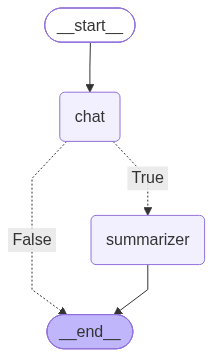

In [183]:
builder= StateGraph(ChatState)

builder.add_node('chat', chat_node)
builder.add_node('summarizer', summarize_conversation)

builder.add_edge(START, 'chat')

builder.add_conditional_edges(
    "chat",
    should_summarize,
    {
        True:"summarizer",
        False: "__end__",
    }
)

builder.add_edge('summarizer', '__end__')

checkpointer= InMemorySaver()

graph= builder.compile(checkpointer=checkpointer)
graph

In [184]:
config= {"configurable":{"thread_id":"thread-1"}}

output1= graph.invoke({'messages':[HumanMessage(content="Hi, my name is aditya")], "summary":""}, config=config)
output2= graph.invoke({'messages':[HumanMessage(content="who is primie minister of india?")]}, config=config)
output3= graph.invoke({'messages':[HumanMessage(content="what is econimy")]}, config=config)
output3= graph.invoke({'messages':[HumanMessage(content="what is science")]}, config=config)
output4= graph.invoke({'messages':[HumanMessage(content="what is my name")]}, config=config)


Messages size during decision: 2
Messages size during decision: 4
Messages size during decision: 6
Messages size during decision: 8
Summary Exist: Here's a summary of our conversation:

1. **Introduction**: We introduced ourselves, and I learned that your name is Aditya.
2. **Current Prime Minister of India**: You asked about the current Prime Minister of India, and I informed you that it's Narendra Modi.
3. **Definition of Economy**: You asked about the meaning of "economy", and I explained that it refers to the system by which a country or society produces, distributes, and consumes goods and services.
4. **Definition of Science**: You asked about the meaning of "science", and I explained that it's a way of acquiring knowledge about the natural world through systematic observation, experimentation, and evidence-based reasoning. I also highlighted the key characteristics of science, its branches, and its importance.

Let me know if you'd like to discuss anything else!
Messages size du

In [185]:
print(output1['messages'][-1].content)
print(output2['messages'][-1].content)
print(output3['messages'][-1].content)
print(output4['messages'][-1].content)

Hello Aditya, it's nice to meet you. Is there something I can help you with or would you like to chat?
The current Prime Minister of India is Narendra Modi. He has been serving as the 14th Prime Minister of India since May 26, 2014.
Science is a fascinating field that seeks to understand the world around us through systematic observation, experimentation, and evidence-based reasoning.

**What is science?**

Science is a way of acquiring knowledge about the natural world through:

1. **Observation**: Carefully watching and recording phenomena, such as the behavior of animals, the motion of objects, or the growth of plants.
2. **Hypothesis**: Formulating educated guesses or explanations for what is observed.
3. **Experimentation**: Designing and conducting tests to verify or falsify hypotheses.
4. **Data analysis**: Collecting and interpreting data from experiments to draw conclusions.
5. **Theory formation**: Developing explanations for the observed phenomena, based on the data and evid

In [186]:
graph.get_state(config=config).values

{'messages': [HumanMessage(content='what is science', additional_kwargs={}, response_metadata={}, id='98f073b7-d8ad-4a39-8bab-588a622a4fbc'),
  AIMessage(content="Science is a fascinating field that seeks to understand the world around us through systematic observation, experimentation, and evidence-based reasoning.\n\n**What is science?**\n\nScience is a way of acquiring knowledge about the natural world through:\n\n1. **Observation**: Carefully watching and recording phenomena, such as the behavior of animals, the motion of objects, or the growth of plants.\n2. **Hypothesis**: Formulating educated guesses or explanations for what is observed.\n3. **Experimentation**: Designing and conducting tests to verify or falsify hypotheses.\n4. **Data analysis**: Collecting and interpreting data from experiments to draw conclusions.\n5. **Theory formation**: Developing explanations for the observed phenomena, based on the data and evidence.\n\n**Key characteristics of science:**\n\n1. **Objecti